In [64]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from initiator import Underlying, Option
from scipy.stats import norm

In [2]:
node_labels = {}
G= nx.DiGraph()
G.add_node((1,1))
node_labels[(1,1)] = 100
G.add_node((2,1))
node_labels[(2,1)] = 80
G.add_node((2,2))
node_labels[(2,2)] = 120
G.add_node((3,1))
node_labels[(3,1)] = 64
G.add_node((3,2))
node_labels[(3,2)] = 96
G.add_node((3,3))
node_labels[(3,3)] = 144
G.add_edge((1,1), (2,1))
G.add_edge((1,1), (2,2))
G.add_edge((2,2), (3,3))
G.add_edge((2,2), (3,2))
G.add_edge((2,1), (3,1))
G.add_edge((2,1), (3,2))

In [3]:
G.nodes()

NodeView(((1, 1), (2, 1), (2, 2), (3, 1), (3, 2), (3, 3)))

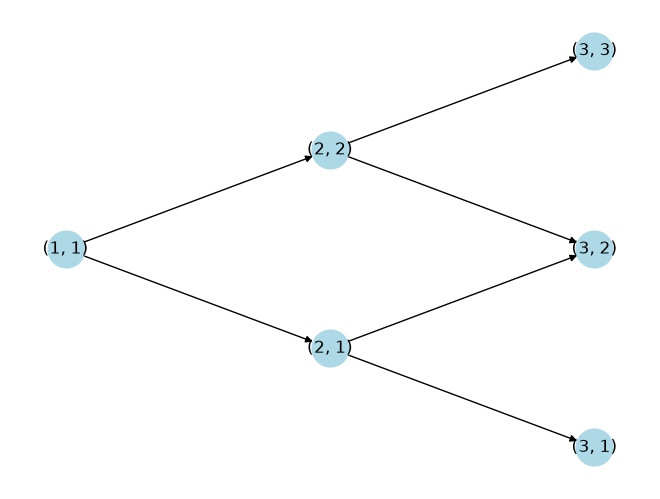

In [4]:
pos = {node: (node[0], node[1] - node[0] / 2) for node in G.nodes()}

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=700,
    arrows=True
)


{(1, 1): Text(1, 0.5, '100'),
 (2, 1): Text(2, 0.0, '80'),
 (2, 2): Text(2, 1.0, '120'),
 (3, 1): Text(3, -0.5, '64'),
 (3, 2): Text(3, 0.5, '96'),
 (3, 3): Text(3, 1.5, '144')}

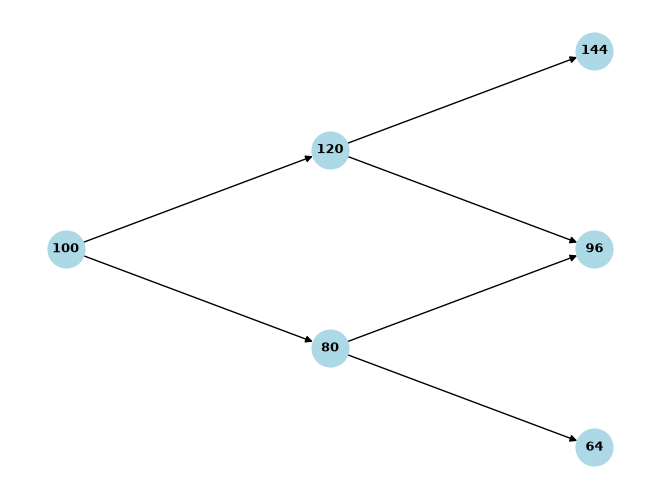

In [5]:
nx.draw(
    G,
    pos,
    with_labels=False,
    node_color="lightblue",
    node_size=700,
    arrows=True
)

nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=9, font_weight='bold')

In [131]:
def build_tree(S, u, d, steps=3):
    G = nx.DiGraph()
    node_labels = {}
    for i in range(steps):
        for j in range(i+1):
            # print('i, j: ', i, j)
            G.add_node((i+1, j+1))
            node_labels[(i+1, j+1)] = round(S * (u**j) * (d**(i-j)), 2)

            if i>0 and (i, j+1) in node_labels:
                G.add_edge((i,j+1), (i+1, j+1))
            if i>0 and (i, j) in node_labels:
                G.add_edge((i, j), (i+1, j+1))
    pos = {node: (node[0], node[1] - node[0] / 2) for node in G.nodes()}

            
    return G, pos, node_labels

# assumption: long only
def calculate_price(G, node_labels, p_u, r, option, steps):
    p_d = 1 - p_u
    op_price_node = {}
    for k, v in dict(sorted(node_labels.items(), key=lambda item: item[0][0], reverse=True)).items():
        # print(k)
        if k[0] == steps:
            op_price_node[k] = max(0, v - option.strike_price) if option.call_or_put == 'call' else max(0, option.strike-price - v)
        else:
            count_step = k[0] + 1
            up = k[1] + 1
            down = k[1]
            up_node = (count_step, up)
            down_node = (count_step, down)
            op_price_node[k] = max(0, (p_u * op_price_node[up_node] + p_d * op_price_node[down_node])/(1+r))
    return op_price_node

underlying = Underlying(current_price=100, predicted_price=100, position='long')
option = Option('call', 'long', 100, 2.7, 'Mar 26', 1, u, quantity=1)


start_node = (1,1)
steps_ = 5
G_b, pos_b, node_labels_b = build_tree(100, 1.25, 0.8, steps=steps_)
op_price_node = calculate_price(G_b, node_labels_b, 0.4818, 0.025, option, steps_)

op_price = op_price_node[start_node]

In [132]:
op_price_node

{(5, 1): 0,
 (5, 2): 0,
 (5, 3): 0,
 (5, 4): 56.25,
 (5, 5): 144.14,
 (4, 1): 0,
 (4, 2): 0,
 (4, 3): 26.440243902439025,
 (4, 4): 96.190636097561,
 (3, 1): 0,
 (3, 2): 12.428204402141585,
 (3, 3): 58.58144669468175,
 (2, 1): 5.8418623228798205,
 (2, 2): 33.81935272067067,
 (1, 1): 18.850163118571174}

In [133]:
op_price

18.850163118571174

In [134]:
def calculate_black_scholes_crr(underlying, option, u, r, steps):
    S = underlying.current_price
    K = option.strike_price
    T = 1/steps
    r = r
    sigma = np.log(u)/np.sqrt(T)

    d1 = np.log(S / K) + (r + 0.5 * sigma**2 * T)/(sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option.call_or_put == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option.call_or_put == 'put':
        price = K * np.exp(-r * T) * norm.cdf(d2) - S * norm.cdf(d1)

    return price
    

In [135]:
black_scholes_crr_price = calculate_black_scholes_crr(underlying, option, 1.25, 0.025, steps_)

print(black_scholes_crr_price)

9.077823289882438


{(1, 1): Text(1, 0.5, '100.0'),
 (2, 1): Text(2, 0.0, '80.0'),
 (2, 2): Text(2, 1.0, '125.0'),
 (3, 1): Text(3, -0.5, '64.0'),
 (3, 2): Text(3, 0.5, '100.0'),
 (3, 3): Text(3, 1.5, '156.25')}

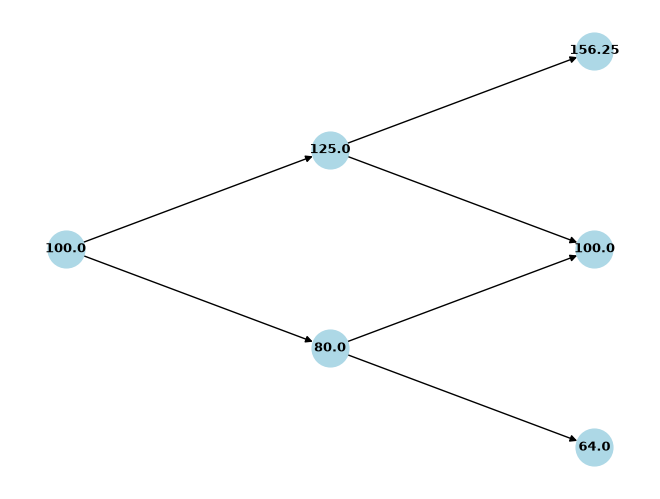

In [55]:
nx.draw(
    G_b,
    pos_b,
    with_labels=False,
    node_color="lightblue",
    node_size=700,
    arrows=True
)

nx.draw_networkx_labels(G_b, pos_b, labels=node_labels_b, font_size=9, font_weight='bold')

In [19]:
(125+80)/2 / 100

1.025

In [22]:
(1/4*156.25 + 1/2*100 + 1/4*64) / (1.025)**2

100.00000000000001